In [1]:
import re

import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score
import random
from sklearn.model_selection import GridSearchCV



keypoints_labels = [
    "head", "nose", "neck", "rightShoulder", "rightElbow", "rightWrist",
    "leftShoulder", "leftElbow", "leftWrist", "rightHip", "rightKnee", "rightAnkle",
    "leftHip", "leftKnee", "leftAnkle", "rightFoot", "leftFoot"
]

In [2]:
frames_df = pd.read_csv("csvs//df.csv")
segments_audio_only = pd.read_csv("csvs//fsao.csv")
segments_with_audio = pd.read_csv("csvs//fswa.csv")
segments_no_audio = pd.read_csv("csvs//fsna.csv")


In [3]:
#Feature Extraction Niewiadomski Helper functions
def has_none(*arrays):
    return any(arr is None or np.any(pd.isnull(arr)) for arr in arrays)

def single_distance(j: np.ndarray) -> np.ndarray:
    res = np.abs(np.diff(j))
    return res

def compute_distance(j1: np.ndarray, j2: np.ndarray) -> np.ndarray:
    """Compute the Euclidean distance between two joint trajectories."""
    diff = map(lambda x: np.linalg.norm(x, axis=0), j1-j2)

    return np.array(list(diff))

def compute_speed(j: np.ndarray) -> np.ndarray:
    """Compute speed from joint positions (frame-wise differences)."""
    speed = np.diff(j, prepend=j[0])
    window_length = min(len(speed) if len(speed) % 2 == 1 else len(speed) - 1, 41)
    if window_length < 5: return speed
    filtered_speed = savgol_filter(speed, window_length=window_length, polyorder=3)
    return filtered_speed

def normalize_vector(v: np.ndarray) -> np.ndarray:
    """Normalize vector to [0, 1]."""
    v_min = np.min(v)
    v_range = np.max(v) - v_min
    return (v - v_min) / v_range if v_range > 0 else np.zeros_like(v)

def threshold_check(value: float, t: float, f: float = 0.2) -> float:
    """Fuzzy threshold check."""
    if value < t:
        return 0.0
    elif value < t + t * f:
        return (value - t) / (t * f)
    else:
        return 1.0


def range_check(value: float, r1: float, r2: float, f: float = 0.2) -> float:
    """Check if a value lies in a range with tolerance."""
    if value < r1 or value > r2:
        return 0.0
    if value < r1 + (r2 - r1) * f:
        return (value - r1) / ((r2 - r1) * f)
    if value > r2 - (r2 - r1) * f:
        return (r2 - value) / ((r2 - r1) * f)
    return 1.0

def frequency_check(signal: np.ndarray, fps: int, f1: float, f2: float, peak_thresh: float = 0.05) -> float:
    """Estimate the frequency of peaks in signal and check if it lies in [f1, f2]."""
    peaks, _ = find_peaks(signal, height=peak_thresh)
    if len(peaks) < 2:
        return 0.0
    duration_seconds = len(signal) / fps
    freq = len(peaks) / duration_seconds
    return range_check(freq, f1, f2, f=0.2)

In [4]:
#Feature computation
def f1_head_horizontal(head: np.ndarray, nose: np.ndarray) -> float:
    if has_none(head, nose): return 0.0
    head_x = np.array(list(map(lambda x: x[0], head)))
    nose_x = np.array(list(map(lambda x: x[0], nose)))
    var_head = np.var(single_distance(head_x))
    var_nose = np.var(single_distance(nose_x))
    return (var_head + var_nose)*0.5

def f2_head_vertical(head: np.ndarray, nose: np.ndarray) -> float:
    if has_none(head, nose): return 0.0
    head_y = np.array(list(map(lambda x: x[1], head)))
    nose_y = np.array(list(map(lambda x: x[1], nose)))
    var_head = np.var(single_distance(head_y))
    var_nose = np.var(single_distance(nose_y))
    return (var_head + var_nose)*0.5

def f3_weight_shift(right_hip: np.ndarray, left_hip: np.ndarray, right_foot: np.ndarray, left_foot: np.ndarray) -> float:
    if has_none(right_hip, left_hip, right_foot, left_foot): return 0.0
    pelvis = 0.5*(right_hip+left_hip)
    d1 = compute_distance(pelvis, right_foot)
    d2 = compute_distance(pelvis, left_foot)
    final = d1/(d1+d2+1e-6)
    return np.var(final)

def f4_knee_bending(
    r_ankle: np.ndarray, r_knee: np.ndarray, r_hip: np.ndarray,
    l_ankle: np.ndarray, l_knee: np.ndarray, l_hip: np.ndarray
) -> float:
    if has_none(r_ankle, r_knee, r_hip, l_ankle, l_knee, l_hip): return 0.0
    def side_bending(ankle, knee, hip):
        d1 = compute_distance(knee, hip)
        d2 = compute_distance(ankle, knee)
        d3 = compute_distance(ankle, hip)
        return d3 / (d1 + d2 + 1e-6)

    f_right = side_bending(r_ankle, r_knee, r_hip)
    f_left = side_bending(l_ankle, l_knee, l_hip)

    combined = f_right + f_left

    return np.cumsum(combined)[-1]

def f6_trunk_straightening (neck: np.ndarray, right_hip: np.ndarray, left_hip: np.ndarray) -> float:
    if has_none(neck, right_hip, left_hip): return 0.0
    pelvis = 0.5*(right_hip+left_hip)

    return np.var(normalize_vector(compute_distance(neck, pelvis)))

def f7_trunk_rocking (neck: np.ndarray, right_hip: np.ndarray, left_hip: np.ndarray) -> float:
    if has_none(neck, right_hip, left_hip): return 0.0
    pelvis = 0.5*(right_hip+left_hip)

    distance = compute_distance(neck, pelvis)
    speed = compute_speed(distance)
    return frequency_check(speed,60, 0.5, 2)

def f8_trunk_throwing(neck: np.ndarray, right_hip: np.ndarray, left_hip: np.ndarray) -> float:
    if has_none(neck, right_hip, left_hip): return 0.0
    pelvis = 0.5*(right_hip+left_hip)

    distance = compute_distance(neck, pelvis)
    speed = compute_speed(distance)
    return threshold_check(np.mean(speed), 0.15, 0.35)

def f9_f10_f11_arm (left_hip: np.ndarray, right_hip: np.ndarray, right_hand: np.ndarray, left_hand) -> (float, float, float):
    if has_none(right_hip, left_hip, right_hand, left_hand): return 0.0, 0.0, 0.0
    pelvis = 0.5*(right_hip+left_hip)
    def side_comp(pelvis, hand):
        d1 = compute_distance(pelvis, hand)
        speed = compute_speed(d1)
        throwing = threshold_check(np.mean(speed), 0.6, 0.33)
        shaking = frequency_check(speed, 60,  1.5, 5.5)
        rocking = frequency_check(speed, 60, 0.5, 2)
        return throwing, shaking, rocking

    l_throwing, l_shaking, l_rocking = side_comp(pelvis, left_hand)
    r_throwing, r_shaking, r_rocking = side_comp(pelvis, right_hand)
    return l_throwing+r_throwing, l_shaking+r_shaking, l_rocking+r_rocking


def f12_arm_straightening (rs, re, rh, ls, le, lh):
    if has_none(rs, re, rh, ls, le, lh): return 0.0
    def side_comp(s, e, h):
        d1 = compute_distance(s, e)
        d2 = compute_distance(e, h)
        d3 = compute_distance(s, h)
        return np.var(d3+(d1+d2+1e-6))
    r = side_comp(rs, re, rh)
    l = side_comp(ls, le, lh)
    return np.var(r+l)

def f13_shoulder_shaking(ls: np.ndarray, rs: np.ndarray) -> float:
    if has_none(ls, rs): return 0.0
    shoulder = rs if None in ls[0] else ls
    d = single_distance(shoulder)
    n = normalize_vector(d)
    n = np.array(list(map(lambda x: x[0], n)))
    return frequency_check(n, 60, 1.5, 5.5)




In [5]:
display(frames_df)
display(segments_audio_only)

,Unnamed: 0,video_id,camera_id,frame_id,agent_id,num_kp,keypoints,occluded,is_laughing_no_audio,is_laughing_only_audio,is_laughing_with_audio
0,0,vid2_seg9,cam2,0,4,17,[[0.43090909 0.59259259]\n [0.44248319 0.56397...,[0 0 1 1 0 0 1 0 0 0 0 1 1 0 1 0 0],0.0,0.0,0.0
1,1,vid2_seg9,cam2,0,27,17,[[0.64545455 0.28787879]\n [0.64532538 0.30976...,[0 1 0 0 0 0 0 0 0 1 1 0 1 1 0 0 1],0.0,0.0,0.0
2,2,vid2_seg9,cam2,0,26,17,[[0.76545455 0.35353535]\n [0.75392673 0.38215...,[0 0 1 0 0 0 0 0 1 1 0 1 0 0 1 0 0],0.0,0.0,0.0
3,3,vid2_seg9,cam2,0,28,17,[[0.68090909 0.52861953]\n [0.68212418 0.50336...,[0 0 0 1 1 1 0 0 1 1 1 1 1 0 1 1 0],0.0,0.0,0.0
4,4,vid2_seg9,cam2,0,13,17,[[0.14360509 0. ]\n [0.20105185 0.00505...,[0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1],0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2278443,2278443,vid3_seg6,cam8,7193,12,18,[[0.14468535 0.73668771]\n [0.1675304 0.70058...,[0 0 1 0 1 0 1 1 0 0 1 1 0 1 1 0 0],0.0,0.0,0.0
2278444,2278444,vid3_seg6,cam8,7193,45,18,[[0.69677418 0.99729239]\n [0.68535165 0.98149...,[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1],0.0,0.0,0.0
2278445,2278445,vid3_seg6,cam8,7193,46,19,[[0.67583288 0.6272563 ]\n [0.65489157 0.59115...,[0 0 1 0 1 0 0 1 0 1 1 1 1 1 1 1 0],0.0,0.0,0.0
2278446,2278446,vid3_seg6,cam8,7194,31,1,[[None None]\n [None None]\n [None None]\n [No...,[None None None None None None None None None ...,0.0,0.0,0.0


,Unnamed: 0,video_id,agent_id,start_frame,end_frame,label,length
0,0,vid2_seg8,1,2935,2954,1.0,20
1,1,vid2_seg8,1,3999,4416,1.0,418
2,2,vid2_seg8,1,5817,5861,1.0,45
3,3,vid2_seg8,1,5926,5949,1.0,24
4,4,vid2_seg8,1,6588,6598,1.0,11
...,...,...,...,...,...,...,...
1568,1568,vid3_seg6,47,2781,3033,0.0,253
1569,1569,vid3_seg6,47,3698,3828,0.0,131
1570,1570,vid3_seg6,47,4739,5232,0.0,494
1571,1571,vid3_seg6,47,6573,6838,0.0,266


In [6]:
def decolumnized_keypoints(keypoints):
    rows = []
    for r in keypoints:
        if isinstance(r, str):
            tokens = re.findall(r'None|[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', r)
            values = [float(t) if t != 'None' else None for t in tokens]
            if len(values) != 34:
                print("OPAAAAAAAAAAAAAAAAAA")
                print(values)
                print(f"⚠️ Bad row: expected 34 values, got {len(values)}")
                print(r)
                continue
            r = np.array(values, dtype=object).reshape(17, 2)


        row = dict(zip(keypoints_labels, r))
        rows.append(row)
    return pd.DataFrame(rows)


def create_dataset(df, segments):
    xs = []
    ys = []
    agent_ids = []

    for _, seg in segments.iterrows():
        vid = seg["video_id"]
        agent = seg["agent_id"]
        start = seg["start_frame"]
        end = seg["end_frame"]
        label = seg["label"]

        frames = df[
            (df["video_id"] == vid) &
            (df["agent_id"] == agent) &
            (df["frame_id"] >= start) &
            (df["frame_id"] <= end)
        ].sort_values("frame_id")
        if len(frames) <= 0: continue
        head_list = np.array(frames["head"].tolist())
        nose_list = np.array(frames["nose"].tolist())
        neck_list = np.array(frames["neck"].tolist())
        rs_list = np.array(frames["rightShoulder"].tolist())
        re_list = np.array(frames["rightElbow"].tolist())
        rw_list = np.array(frames["rightWrist"].tolist())
        ls_list = np.array(frames["leftShoulder"].tolist())
        le_list = np.array(frames["leftElbow"].tolist())
        lw_list = np.array(frames["leftWrist"].tolist())
        rh_list = np.array(frames["rightHip"].tolist())
        rk_list = np.array(frames["rightKnee"].tolist())
        ra_list = np.array(frames["rightAnkle"].tolist())
        lh_list = np.array(frames["leftHip"].tolist())
        lk_list = np.array(frames["leftKnee"].tolist())
        la_list = np.array(frames["leftAnkle"].tolist())
        f1 = f1_head_horizontal(head_list, nose_list)
        f2 = f2_head_vertical(head_list, nose_list)
        f3 = f3_weight_shift(rh_list, lh_list, ra_list, la_list)
        f4 = f4_knee_bending(rh_list, rk_list, ra_list, lh_list, lk_list, la_list)
        f6 = f6_trunk_straightening(neck_list, rh_list, lh_list)
        f7 = f7_trunk_rocking(neck_list, rh_list, lh_list)
        f8 = f8_trunk_throwing(neck_list, rh_list, lh_list)
        f9, f10, f11 = f9_f10_f11_arm(lh_list, rh_list, rw_list, lw_list)
        f12 = f12_arm_straightening(rs_list, re_list, rw_list, ls_list, le_list, lw_list)
        f13 = f13_shoulder_shaking(rs_list, ls_list)

        f_vec = [f1, f2, f3, f4, f6, f7, f8, f9, f10, f11, f12, f13]
        xs.append(f_vec)
        ys.append(label)
        agent_ids.append(agent)

    return xs, ys, agent_ids



In [7]:
fdf = frames_df.drop(columns=['keypoints']).join(decolumnized_keypoints(frames_df['keypoints']))
display(fdf)


,Unnamed: 0,video_id,camera_id,frame_id,agent_id,num_kp,occluded,is_laughing_no_audio,is_laughing_only_audio,is_laughing_with_audio,...,leftElbow,leftWrist,rightHip,rightKnee,rightAnkle,leftHip,leftKnee,leftAnkle,rightFoot,leftFoot
0,0,vid2_seg9,cam2,0,4,17,[0 0 1 1 0 0 1 0 0 0 0 1 1 0 1 0 0],0.0,0.0,0.0,...,"[0.3778609, 0.53198653]","[0.41292263, 0.60606061]","[0.48234412, 0.56902357]","[0.48685201, 0.54545455]","[0.4913599, 0.54545455]","[0.42103683, 0.54545455]","[0.43726523, 0.53198653]","[0.44628101, 0.53535354]","[0.50668672, 0.52356902]","[0.45056097, 0.51010101]"
1,1,vid2_seg9,cam2,0,27,17,[0 1 0 0 0 0 0 0 0 1 1 0 1 1 0 0 1],0.0,0.0,0.0,...,"[0.5753179, 0.23737374]","[0.56005986, 0.32996633]","[0.56544505, 0.39225589]","[0.56275245, 0.39225589]","[0.55826479, 0.41750842]","[0.56813764, 0.26767677]","[0.56095739, 0.30808081]","[0.55108454, 0.35016835]","[0.58878087, 0.42087542]","[0.57083024, 0.33501684]"
2,2,vid2_seg9,cam2,0,26,17,[0 0 1 0 0 0 0 0 1 1 0 1 0 0 1 0 0],0.0,0.0,0.0,...,"[0.79162307, 0.40740741]","[0.75841439, 0.39057239]","[0.71892299, 0.28619529]","[0.68571431, 0.34848485]","[0.68032912, 0.34680135]","[0.73687362, 0.3013468]","[0.69020197, 0.3956229]","[0.67763652, 0.39057239]","[0.66327602, 0.35016835]","[0.65968589, 0.41750842]"
3,3,vid2_seg9,cam2,0,28,17,[0 0 0 1 1 1 0 0 1 1 1 1 1 0 1 1 0],0.0,0.0,0.0,...,"[0.60044879, 0.51010101]","[0.60314138, 0.496633]","[0.66776367, 0.56734007]","[0.634555, 0.53872054]","[0.62737474, 0.56060606]","[0.60044879, 0.51515152]","[0.60134632, 0.53535354]","[0.59416607, 0.54208754]","[0.61839942, 0.49326599]","[0.58608828, 0.496633]"
4,4,vid2_seg9,cam2,0,13,17,[0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1],0.0,0.0,0.0,...,"[0.19744554, 0.0016835]","[0.2515402, 0.0016835]","[0.19203607, 0.00505051]","[0.19654396, 0.0]","[0.23260707, 0.00505051]","[0.22809918, 0.53703704]","[0.21187078, 0.0016835]","[0.2515402, 0.02356902]","[0.21547709, 0.0]","[0.21457552, 0.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2278443,2278443,vid3_seg6,cam8,7193,12,18,[0 0 1 0 1 0 1 1 0 0 1 1 0 1 1 0 0],0.0,0.0,0.0,...,"[0.17451084, 0.65094764]","[0.20370174, 0.66110106]","[0.25891062, 0.69720215]","[0.25637228, 0.66110106]","[0.31792701, 0.68592056]","[0.24050766, 0.65997291]","[0.25637228, 0.65997291]","[0.27414066, 0.66787002]","[0.33188788, 0.66787002]","[0.28810153, 0.64305052]"
2278444,2278444,vid3_seg6,cam8,7193,45,18,[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1],0.0,0.0,0.0,...,"[0.70375461, 0.99503607]","[0.69677418, 0.98262633]","[0.6326811, 0.99390791]","[0.63204652, 0.9916516]","[0.6288736, 0.9916516]","[0.65362241, 0.9916516]","[0.64854573, 0.99503607]","[0.64219988, 0.99277976]","[0.62316233, 0.9916516]","[0.64664197, 0.99277976]"
2278445,2278445,vid3_seg6,cam8,7193,46,19,[0 0 1 0 1 0 0 1 0 1 1 1 1 1 1 1 0],0.0,0.0,0.0,...,"[0.60285562, 0.65320395]","[0.60602854, 0.61484655]","[0.6244315, 0.5697202]","[0.62633526, 0.57536099]","[0.62316233, 0.58100179]","[0.59968269, 0.61710287]","[0.58826016, 0.61033392]","[0.58064515, 0.61710287]","[0.62062399, 0.57423284]","[0.57176096, 0.59228338]"
2278446,2278446,vid3_seg6,cam8,7194,31,1,[None None None None None None None None None ...,0.0,0.0,0.0,...,"[None, None]","[None, None]","[None, None]","[None, None]","[None, None]","[None, None]","[None, None]","[None, None]","[None, None]","[0.4892209305697656, 0.2517084282460137]"


In [8]:
xna, yna, ana = create_dataset(fdf, segments_no_audio)
xoa, yoa, aoa = create_dataset(fdf, segments_audio_only)
xwa, ywa, awa = create_dataset(fdf, segments_with_audio)
print(len(xna), len(yna), len(ana))
print(len(xoa), len(yoa), len(aoa))
print(len(xwa), len(ywa), len(awa))

C:\Users\Vassil.Guenov\PyCharmMiscProject\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:4268: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\Vassil.Guenov\PyCharmMiscProject\.venv\Lib\site-packages\numpy\_core\_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
C:\Users\Vassil.Guenov\PyCharmMiscProject\.venv\Lib\site-packages\numpy\_core\_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


1184 1184 1184
1573 1573 1573
1132 1132 1132


In [10]:
X_train, X_test, y_train, y_test = train_test_split(xna, yna, test_size=0.2, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.8776371308016878
              precision    recall  f1-score   support

         0.0       0.90      0.88      0.89       135
         1.0       0.85      0.87      0.86       102

    accuracy                           0.88       237
   macro avg       0.87      0.88      0.88       237
weighted avg       0.88      0.88      0.88       237



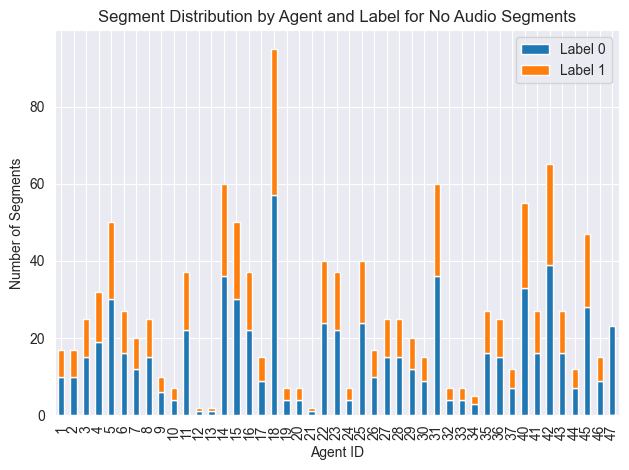

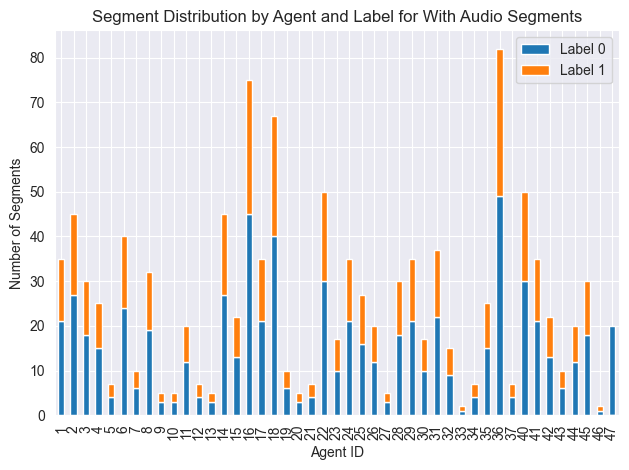

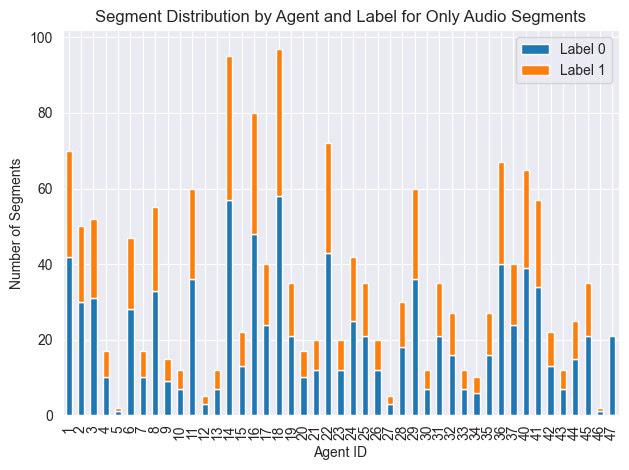

In [11]:
def visualize_num_of_segments(agents, y, label):
    df = pd.DataFrame({'agent_id': agents, 'label': y})
    counts = df.groupby(['agent_id', 'label']).size().unstack(fill_value=0)

    # Plot
    counts.plot(kind='bar', stacked=True)
    plt.xlabel("Agent ID")
    plt.ylabel("Number of Segments")
    plt.title(f"Segment Distribution by Agent and Label for {label}")
    plt.legend(["Label 0", "Label 1"])
    plt.tight_layout()
    plt.show()
visualize_num_of_segments(ana, yna, "No Audio Segments")
visualize_num_of_segments(awa, ywa, "With Audio Segments")
visualize_num_of_segments(aoa, yoa, "Only Audio Segments")

In [12]:
def split_by_agent(x, y, agents, low, upper):
    x = np.array(x)
    y = np.array(y)
    agents = np.array(agents)

    unique_agents = list(np.unique(agents))
    selected_agents = []
    total_samples = len(x)
    current_ratio = 0.0

    # Select agents until the proportion of data hits the desired range
    while current_ratio < low and unique_agents:
        idx = random.randrange(len(unique_agents))
        selected_agent = unique_agents.pop(idx)
        agent_mask = agents == selected_agent
        selected_count = np.sum(agent_mask)
        new_ratio = (current_ratio * total_samples + selected_count) / total_samples
        if new_ratio > upper:
            continue
        selected_agents.append(selected_agent)
        current_ratio = new_ratio

    test_mask = np.isin(agents, selected_agents)
    train_mask = ~test_mask

    x_train = x[train_mask]
    y_train = y[train_mask]
    x_test = x[test_mask]
    y_test = y[test_mask]

    assert len(x_train) + len(x_test) == len(x)
    assert len(y_train) + len(y_test) == len(y)

    return x_train, y_train, x_test, y_test

In [17]:
def plot_feature_importances(importances, feature_names, title="Feature Importances"):
    indices = np.argsort(importances)[::-1]
    print(importances)
    # plt.figure(figsize=(10, 5))
    # plt.title(title)
    # plt.bar(range(len(importances)), importances[indices])
    # plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
    # plt.tight_layout()
    # plt.show()


def train_model(x, y, agents, k, label):
    all_f1 = []
    all_acc = []
    all_top_features = []
    y = [0 if np.isnan(a) else a for a in y]


    for i in range(k):
        x_train, y_train, x_test, y_test = split_by_agent(x, y, agents, 0.2, 0.23)

        param_grid = {
            'n_estimators': [100, 200],
            'max_depth': [None, 10],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2],
            'max_features': ['sqrt', 'log2'],
            'bootstrap': [True, False],
        }

        clf = GridSearchCV(RandomForestClassifier(), param_grid, cv=3, scoring='f1', n_jobs=-1)
        clf.fit(x_train, y_train)
        y_pred = clf.predict(x_test)
        best_rf = clf.best_estimator_

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        all_acc.append(acc)
        all_f1.append(f1)

        importances = best_rf.feature_importances_
        feature_names = ["head horizontal", "head vertical", "weight_shift", "knee bending", "trunk straightening", "trunk rocking", "trunk throwing", "arm throwing", "arm shaking", "arm straightening", "shoulder shaking"]
        top_idx = np.argmax(importances)
        top_feature = feature_names[top_idx]
        all_top_features.append(top_feature)

        print(f"Run {i + 1} for label: {label}:")
        print(classification_report(y_test, y_pred))
        plot_feature_importances(importances, feature_names)


    print(f"Mean Accuracy for {label}: {np.mean(all_acc):.4f}")
    print(f"Mean F1 Score for {label}: {np.mean(all_f1):.4f}")
    return all_acc, all_f1, all_top_features

In [18]:
acc_na, fna, tfna = train_model(xna, yna, ana, 10, "No Audio Segments")
acc_oa, foa, tfoa = train_model(xoa, yoa, aoa, 10, "Only Audio Segments")
acc_wa, fwa, tfwa = train_model(xwa, ywa, awa, 10, "With Audio Segments")


Run 1 for label: No Audio Segments:
              precision    recall  f1-score   support

         0.0       0.84      0.91      0.88       162
         1.0       0.82      0.70      0.76        94

    accuracy                           0.84       256
   macro avg       0.83      0.81      0.82       256
weighted avg       0.84      0.84      0.83       256

[0.08543669 0.0863024  0.08423845 0.6304401  0.0995348  0.
 0.         0.         0.         0.         0.         0.01404756]
Run 2 for label: No Audio Segments:
              precision    recall  f1-score   support

         0.0       0.91      0.82      0.86       154
         1.0       0.77      0.88      0.82       104

    accuracy                           0.84       258
   macro avg       0.84      0.85      0.84       258
weighted avg       0.85      0.84      0.85       258

[0.09507016 0.08265376 0.08209643 0.62313927 0.10116392 0.
 0.         0.         0.         0.         0.         0.01587646]
Run 3 for label: No 

In [133]:
def find_incomplete_rows_with_valid_previous_loop(df, keypoint_labels):
    bad_rows = []
    for label in keypoint_labels:
        for i in range(1, len(df)):  # start from 1 to always have a "previous" row
            curr = df.iloc[i]
            prev = df.iloc[i - 1]
            # Check if video_id and agent_id match
            if curr['video_id'] != prev['video_id'] or curr['agent_id'] != prev['agent_id']:
                continue

            # Check if any current keypoint has a None
            if curr[keypoint_labels[label]] is not None or i == 0:
                continue

            if prev[keypoint_labels[label]] is None:
                continue
            # Check if all previous keypoints are valid

            bad_rows.append(i)  # store index or row

    # Return the selected rows
    return df.iloc[bad_rows]

display(find_incomplete_rows_with_valid_previous_loop(fdf, keypoints_labels))

,Unnamed: 0,video_id,camera_id,frame_id,agent_id,num_kp,occluded,is_laughing_no_audio,is_laughing_only_audio,is_laughing_with_audio,...,leftElbow,leftWrist,rightHip,rightKnee,rightAnkle,leftHip,leftKnee,leftAnkle,rightFoot,leftFoot
